Utwórz bazę sklepu: customers , orders , order_items (zawiera szczegóły produktów w
zamówieniu

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

#BAZA DANYCH
# Tworzenie przykładowych danych dla tabeli customers
customers_data = {
    'customer_id': [1, 2, 3],
    'customer_name': ['John', 'Jane', 'Bob']
}
customers_df = pd.DataFrame(customers_data)
# Tworzenie przykładowych danych dla tabeli orders
orders_data = {
    'order_id': [1, 2, 3],
    'customer_id': [1, 2, 3],
    'order_date': ['2023-01-01', '2023-01-02', '2023-01-03']
}
orders_df = pd.DataFrame(orders_data)
# Tworzenie przykładowych danych dla tabeli order_items
order_items_data = {
    'order_item_id': [1, 2, 3],
    'order_id': [1, 2, 3],
    'product_id': [1, 2, 3],
    'quantity': [2, 1, 10],
    'price': [1000.0, 50.0, 500.0]
}
order_items_df = pd.DataFrame(order_items_data)



Zadanie 10 – HAVING i grupowanie
Wymagania:
(średnie)
Używając danych sprzedażowych, pogrupuj według kategorii
Użyj HAVING aby znaleźć tylko kategorie z przychodem > 1000 PLN
Oblicz liczbę transakcji, łączny przychód i średnią dla każdej kategorii
Posortuj według łącznego przychodu


In [12]:
# Zapisdo sql
customers_df.to_sql('customers', conn, if_exists='replace', index=False)
orders_df.to_sql('orders', conn, if_exists='replace', index=False)
order_items_df.to_sql('order_items', conn, if_exists='replace', index=False)

# Zapytanie
query = """
SELECT
    c.customer_name,
    SUM(oi.quantity * oi.price) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_transactions,
    AVG(oi.quantity * oi.price) AS average_revenue
FROM
    customers c
JOIN
    orders o ON c.customer_id = o.customer_id       
JOIN
    order_items oi ON o.order_id = oi.order_id
GROUP BY
    c.customer_name
HAVING  
    total_revenue > 1000
ORDER BY
    total_revenue DESC; 
"""
# Wykonanie zapytania
result_df = pd.read_sql_query(query, conn)
print(result_df)



  customer_name  total_revenue  total_transactions  average_revenue
0           Bob         5000.0                   1           5000.0
1          John         2000.0                   1           2000.0


11. ✏ Zadanie 11 – Złożone filtrowanie
Dataset: Titanic
Wymagania:
Znajdź pasażerów 1 klasy, kobiety, które przeżyły
Oblicz średni wiek i średnią cenę biletu dla tej grupy
Porównaj z mężczyznami z 3 klasy którzy nie przeżyli
Stwórz wykres porównawczy (barplot)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071  

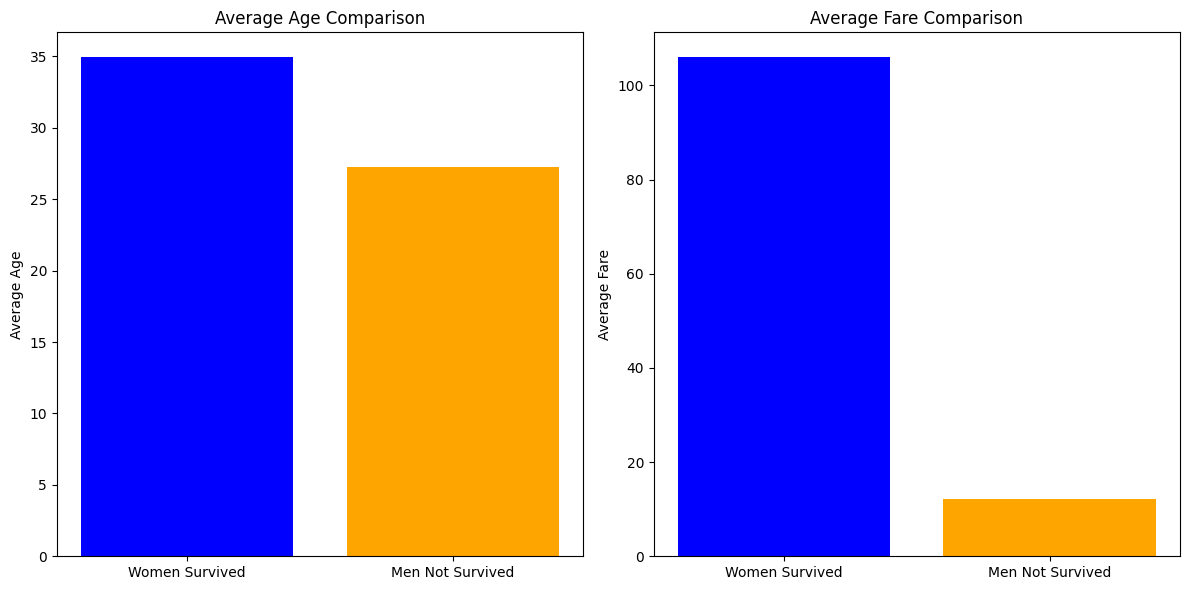

In [14]:
# Wczytywanie datasetu Titanic
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)
# Wyświetlanie informacji
print(titanic_df.info())
# Wyświetlanie statystyk
print(titanic_df.describe())

#ZADANIE
# łączenie z bazą danych
conn = sqlite3.connect('titanic.db')
# Zapis danych do bazy danych
titanic_df.to_sql('titanic', conn, if_exists='replace', index=False)

# Zapytanie, kobiety, 1 klasa, przezyly
women_1_survived = """
SELECT  
    AVG(Age) AS srednia_wieku,
    AVG(Fare) AS srednia_cena_biletu
FROM titanic
WHERE Pclass = 1 AND Sex = 'female' AND Survived = 1
"""

# Zapytanie mezczyzni, 3 klasa, nie przezyli
men_3_not_survived = """
SELECT
    AVG(Age) AS srednia_wieku,
    AVG(Fare) AS srednia_cena_biletu   
FROM titanic
WHERE Pclass = 3 AND Sex = 'male' AND Survived = 0
"""


# wykonanie dwoch zapytań i zapis wyników do DataFrame
women_1_survived_df = pd.read_sql_query(women_1_survived, conn)   
men_3_not_survived_df = pd.read_sql_query(men_3_not_survived, conn)

# Porównanie
porownanie_df = pd.DataFrame({
    'Group': ['Women Survived', 'Men Not Survived'],
    'Average Age': [round(women_1_survived_df['srednia_wieku'][0], 2), round(men_3_not_survived_df['srednia_wieku'][0], 2)],
    'Average Fare': [round(women_1_survived_df['srednia_cena_biletu'][0], 2), round(men_3_not_survived_df['srednia_cena_biletu'][0], 2)]
})
print(porownanie_df)


# Tworzenie wykresu porównawczego
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Wykres dla średniego wieku
ax[0].bar(porownanie_df['Group'], porownanie_df['Average Age'], color=['blue', 'orange'])
ax[0].set_title('Average Age Comparison')
ax[0].set_ylabel('Average Age')
# Wykres dla średniej ceny biletu
ax[1].bar(porownanie_df['Group'], porownanie_df['Average Fare'], color=['blue', 'orange'])
ax[1].set_title('Average Fare Comparison')  
ax[1].set_ylabel('Average Fare')
plt.tight_layout()
plt.show()



